# Introduction to Machine Learning -- MC886
# Hands-on I: Introduction to Pytorch

**Professor:** Marcelo da Silva Reis\
**PED:** Daniel Gardin Gratti

## Is PyTorch = Numpy + GPU?

For now, the only difference PyTorch offers that numpy doesn't is GPU support.
However, this is not even the biggest difference between the frameworks.

> PyTorch is a **Machine Learning framework** because it can automatically calculate **gradients**.

As we are going to see in this course, Machine Learning is built upon the gradient descent algorithm to guide the parameter update and increase a desired criteria.

We can create, for example, a tensor that requires gradient and any operation made with them are stored for further gradient computation.

In [2]:
import torch

In [3]:
target = torch.tensor([1.0, 0.0])

predictions = torch.tensor([0.9, 0.1], requires_grad=True)

diff = predictions - target
diff

tensor([-0.1000,  0.1000], grad_fn=<SubBackward0>)

In [4]:
loss = diff.pow(2).mean()
loss

tensor(0.0100, grad_fn=<MeanBackward0>)

In [5]:
loss.backward() # Use the autograd system to compute the backward pass.
predictions.grad

tensor([-0.1000,  0.1000])

PyTorch's autograd system stores the computation graph during the forward pass that produced the output value

$$\ell = \frac{1}{n}\sum_i^n \left(\text{pred}_i - \text{target}_i\right)^2$$

And only after we call `.backward()`, it backward passes all operations we have done and produce the gradient

$$\nabla_{\text{pred}} \ell = \left(\frac{\partial \ell}{\partial \text{pred}_i}\right)_i = \left(\frac{2}{n}(\text{pred}_i - \text{target}_i)\right)_i$$

The main difference between linear regression and the example above is that `predictions` are obtained as a linear combination between the input and the model weights.

Therefore, we can implement a very simple linear regression by defining the weights and bias of our model as

$$w \in \mathbb{R}^n, b \in \mathbb{R}$$
where $n$ is the number of input features, and

$$\text{pred}(x) = w^T x + b$$

However, we may store the data as a tensor with shape `[batch, n_features]` and, as our weights has shape `[n_features]` and broadcast is done from the right, we can obtain our prediction by multiplying `X @ w + b`

In [6]:
def initialize_weights(n_features: int) -> torch.Tensor:
    return torch.randn(n_features, requires_grad=True)

def initialize_bias() -> torch.Tensor:
    return torch.rand(1, requires_grad=True)

def predict(X: torch.Tensor, weights: torch.Tensor, bias: torch.Tensor) -> torch.Tensor:
    return (X @ weights + bias).squeeze()

def error(predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return (predictions - targets).pow(2).mean()

## Managing datasets

#### **Overview**

Now we'll explore how to build, train, and test models using **PyTorch**. The process involves:
- **Training**: Optimize the model using labeled data.
- **Validation**: Tune hyperparameters and monitor overfitting.
- **Testing**: Evaluate the final model on unseen data.

Flow:

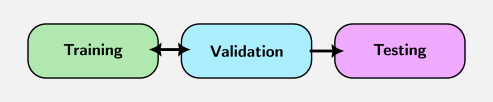


Source: Marcos Vinicius Souza Freire


For training, we need to process our dataset into a tensor-like representation to feed it to our models.

After we have our tensors, we need to split them into different bins: One for training, another for validating and the last one for testing.
This is importante because whenever we use some data to make decisions about our model, we cannot longer use the same data to test the **generalization power** of our model.
We are going further discuss this aspect of learning later, now we need a practical way of dealing with data.

In practice, pytorch works with two main abstractions:
- **`Dataset`**: Stores data samples and their labels (e.g., images and classes).
- **`DataLoader`**: Batches data, shuffles it (if needed), and supports multiprocessing for efficiency.

##### Notes
- **Training**: Use `shuffle=True` to randomize data and reduce overfitting.
- **Testing**: Use `shuffle=False` for consistent evaluation.
- **Mini-batches**: `DataLoader` groups data into batches (e.g., 5 samples per batch).

For our session, we are going to use the [California housing dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

In [7]:
import os
import tarfile
import urllib.request
import pandas as pd

# Define function to download the data from the internet

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join(".", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

os.makedirs(HOUSING_PATH, exist_ok=True)
tgz_path = os.path.join(HOUSING_PATH, "housing.tgz")
urllib.request.urlretrieve(HOUSING_URL, tgz_path)
housing_tgz = tarfile.open(tgz_path)
housing_tgz.extractall(path=HOUSING_PATH)
housing_tgz.close()

/tmp/ipykernel_4130/86287139.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=HOUSING_PATH)


In [8]:
df = pd.read_csv(os.path.join(HOUSING_PATH, "housing.csv"))
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Before we analyze the data to make suppositions about the prediction model, we split the dataset into
- Training (70%)
- Testing (30%)

In [9]:
df_train = df.sample(frac=0.8, random_state=42)
df_test = df.drop(df_train.index)

df_train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16305.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.565125,35.625094,28.657703,2629.982376,536.053542,1421.894016,498.092054,3.870452,206773.380875
std,2.000526,2.132973,12.590337,2183.538462,420.135537,1109.246995,380.460835,1.896270,115239.666174
min,-124.350000,32.540000,1.000000,2.000000,1.000000,5.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1445.000000,297.000000,788.000000,281.000000,2.566625,119400.000000
50%,-118.490000,34.255000,29.000000,2123.000000,433.000000,1165.000000,409.000000,3.534850,179850.000000
75%,-118.010000,37.710000,37.000000,3146.000000,644.000000,1722.000000,602.250000,4.743250,265225.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,28566.000000,6082.000000,15.000100,500001.000000


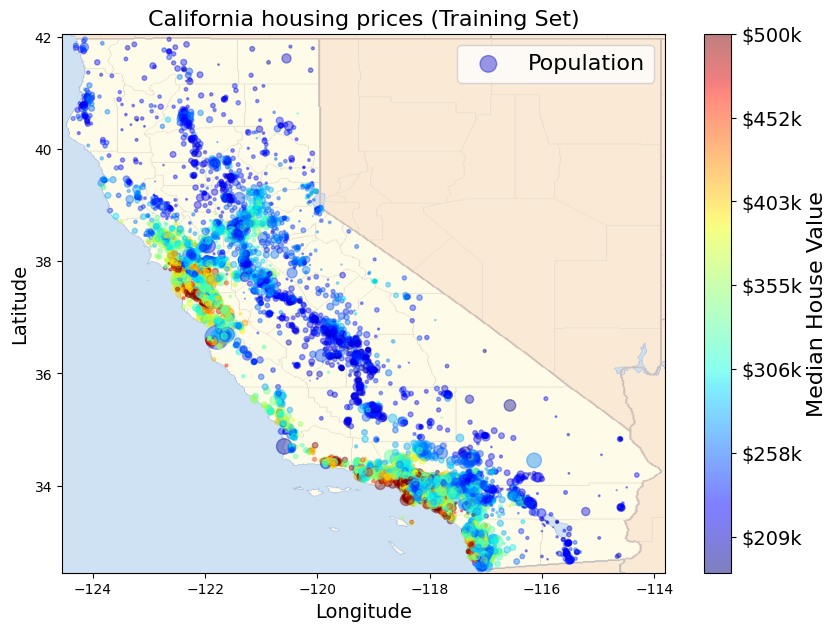

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
PROJECT_ROOT_DIR = "./housing"

images_path = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))


california_img=mpimg.imread(os.path.join(images_path, filename))
ax = df_train.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=df_train['population']/100, label="Population",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = df_train["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.title("California housing prices (Training Set)", fontsize=16)

plt.legend(fontsize=16)
plt.show()

> What observations can we draw between our variables and the outcome?

- Does longitude/latitude have a linear relationship with the median house value?
- Does the median house value increases as the median income increases?
- Is `ocean_proximity` a good predictor?
- What features are most correlated with the outcome?

> **Exploration Data Analysis (EDA)** can answer our hypothesis **before** we select an appropriate model

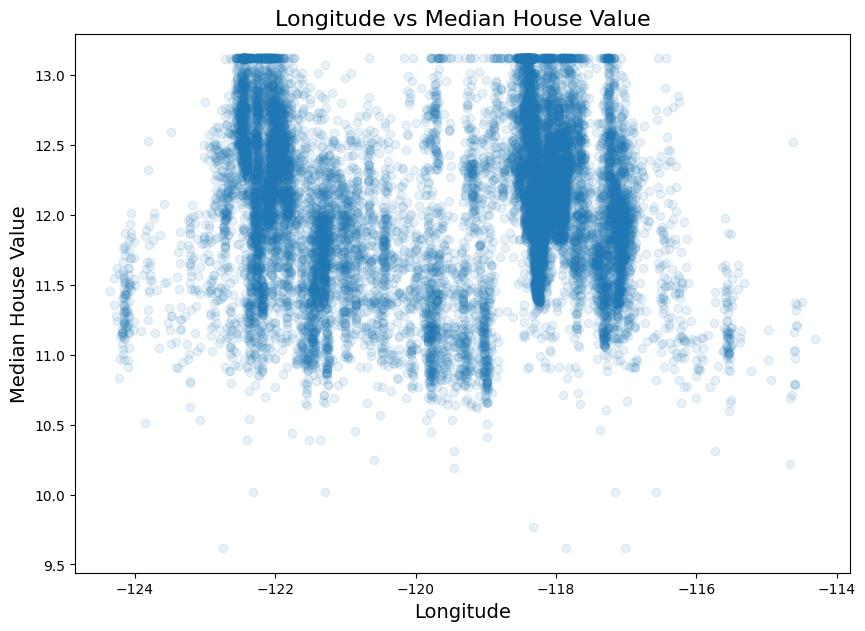

In [11]:
# Does longitude/latitude have a linear relationship with the median house value?

plt.figure(figsize=(10,7))
plt.scatter(df_train["longitude"], np.log(df_train["median_house_value"]), alpha=0.1)
plt.xlabel("Longitude", fontsize=14)
plt.ylabel("Median House Value", fontsize=14)
plt.title("Longitude vs Median House Value", fontsize=16)
plt.show()

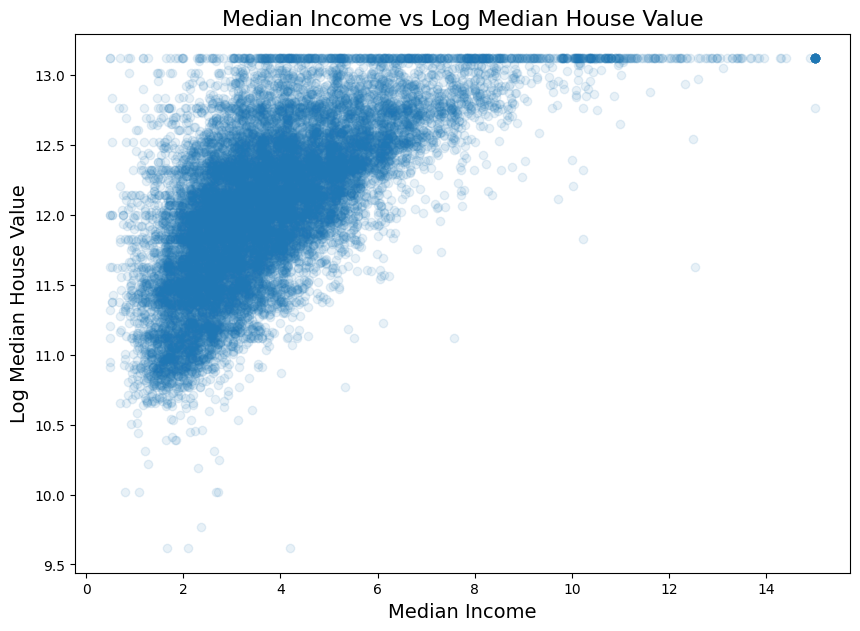

In [12]:
# Does the median house value increases as the median income increases?

plt.figure(figsize=(10,7))
plt.scatter(df_train["median_income"], np.log(df_train["median_house_value"]), alpha=0.1)
plt.xlabel("Median Income", fontsize=14)
plt.ylabel("Log Median House Value", fontsize=14)
plt.title("Median Income vs Log Median House Value", fontsize=16)

plt.show()

<Figure size 1000x700 with 0 Axes>

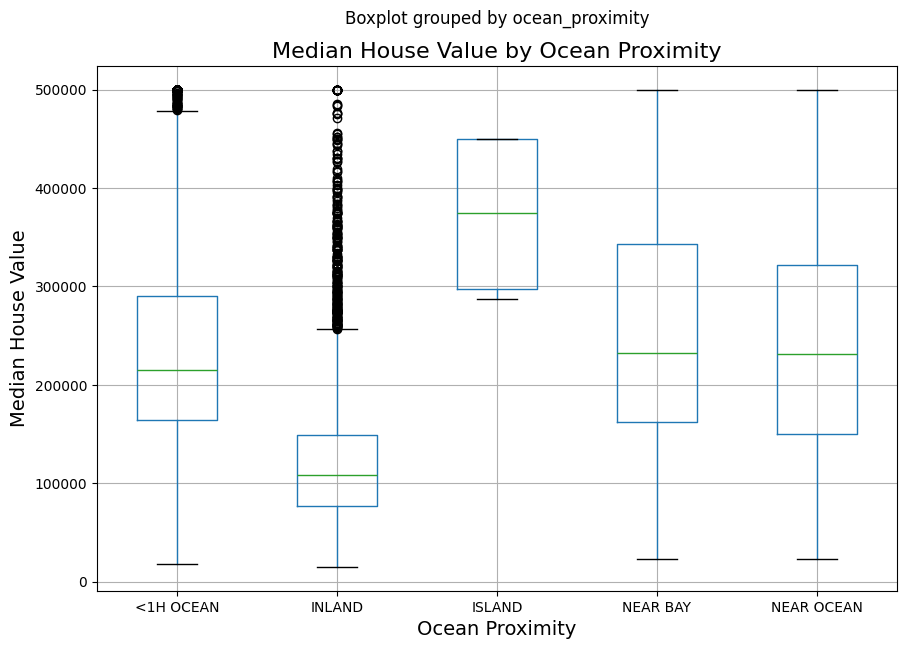

In [13]:
# Is `ocean_proximity` a good predictor?
# ocean_proximity is a categorical attribute, plot boxplots of median_house_value for each category of ocean_proximity
plt.figure(figsize=(10,7))

df_train.boxplot(column="median_house_value", by="ocean_proximity", figsize=(10,7))
plt.xlabel("Ocean Proximity", fontsize=14)
plt.ylabel("Median House Value", fontsize=14)
plt.title("Median House Value by Ocean Proximity", fontsize=16)

plt.show()

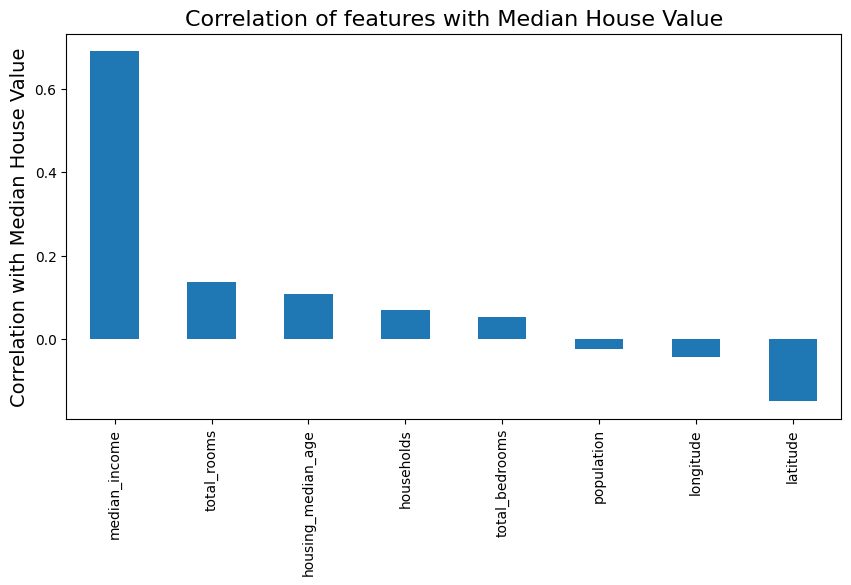

In [14]:
# What features are most correlated with the outcome?

plt.figure(figsize=(10,5))
corr_matrix = df_train.corr(numeric_only=True)

corr_values = corr_matrix["median_house_value"].drop("median_house_value").sort_values(ascending=False)

corr_values.plot(kind="bar")
plt.ylabel("Correlation with Median House Value", fontsize=14)
plt.title("Correlation of features with Median House Value", fontsize=16)
plt.show()

### Transforming the data into tensors

Our data has a problem: Tensors can only be numeric, and `ocean_proximity` is a **categorical feature**.
To turn it into a numeric value, we can use a **one-hot encoding**, which creates an additional feature for each possible value in `ocean_proximity` and sets as 1 the feature with the respective value, and zero to the remaining.

Other issues with our data are the scales.
In the `describe` method, we have seen that feature ranges vary significantly, this can slow down the model training due to a ill-conditioned hessian (Meaning that the minimum is too stretched and we may need a lot of iterations to achieve it).

To help with this, we can use a normalization technique called **Z-score**, which centralizes the features, shifting the original distribution to have zero-mean and unit variance.

Additionally, as our output also varies a lot and non uniform (small differences in cheap houses are more significant than the same amount in more expensive ones), we take the logarithm of the outcome as our prediction value.

In [15]:
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        # Initialize the dataset (e.g., load data, preprocess)

        # ocean_proximity is a categorical attribute, we need to encode it as a one-hot vector
        self.data = df.copy()
        self.data = pd.get_dummies(self.data, columns=["ocean_proximity"], drop_first=True)
        self.data = self.data.drop(columns=["median_house_value"]).fillna(0).astype(np.float32)

        self.label = np.log(torch.tensor(df["median_house_value"].values, dtype=torch.float32))
        self.data = torch.tensor(self.data.values, dtype=torch.float32)

        # Normalize the data
        self.data = (self.data - self.data.mean(dim=0)) / self.data.std(dim=0)        
    
    def __getitem__(self, index):
        # Return a single sample (e.g., input tensor, label)
        return self.data[index], self.label[index]
    
    def __len__(self):
        # Return total number of samples (size of the dataset)
        return len(self.data)


## Building our linear model

Median income has a high correlation with the outcome, not quite linear, but we can measure how much better a linear estimator is than the mean estimator, for example.

In [16]:
W = initialize_weights(12)
b = initialize_bias()

train_loader = DataLoader(MyDataset(df_train), batch_size=128, shuffle=True)

n_epochs = 20
learning_rate = 0.001

losses = []
for epoch in range(n_epochs):
    epoch_loss = 0.0

    for batch, (X_batch, y_batch) in enumerate(train_loader):
        # Compute predictions
        predictions = predict(X_batch, W, b)

        # Compute error
        loss = error(predictions, y_batch)

        # Backpropagation
        loss.backward()

        # Update weights and bias using gradient descent
        with torch.no_grad():
            W -= learning_rate * W.grad
            b -= learning_rate * b.grad

            # Zero the gradients after updating
            W.grad.zero_()
            b.grad.zero_()

        epoch_loss += loss.item()
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")

Epoch 1/20, Average Loss: 101.5770
Epoch 2/20, Average Loss: 60.9127
Epoch 3/20, Average Loss: 36.7007
Epoch 4/20, Average Loss: 22.2256
Epoch 5/20, Average Loss: 13.5569
Epoch 6/20, Average Loss: 8.3546
Epoch 7/20, Average Loss: 5.2258
Epoch 8/20, Average Loss: 3.3382
Epoch 9/20, Average Loss: 2.1947
Epoch 10/20, Average Loss: 1.4976
Epoch 11/20, Average Loss: 1.0694
Epoch 12/20, Average Loss: 0.8029
Epoch 13/20, Average Loss: 0.6345
Epoch 14/20, Average Loss: 0.5256
Epoch 15/20, Average Loss: 0.4531
Epoch 16/20, Average Loss: 0.4031
Epoch 17/20, Average Loss: 0.3672
Epoch 18/20, Average Loss: 0.3403
Epoch 19/20, Average Loss: 0.3192
Epoch 20/20, Average Loss: 0.3020


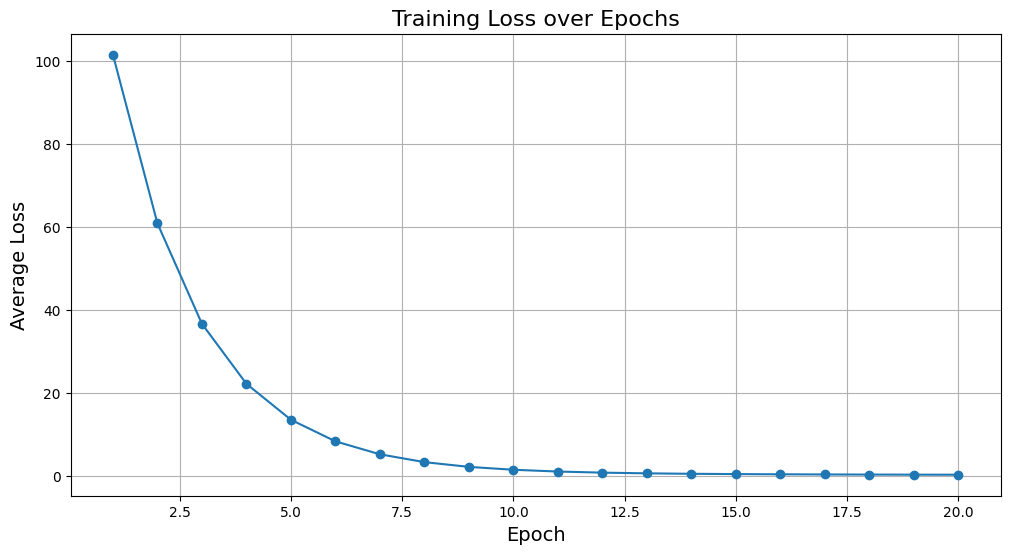

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(range(1, n_epochs + 1), losses, marker='o')
plt.title('Training Loss over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Average Loss', fontsize=14)
plt.grid()
plt.show()

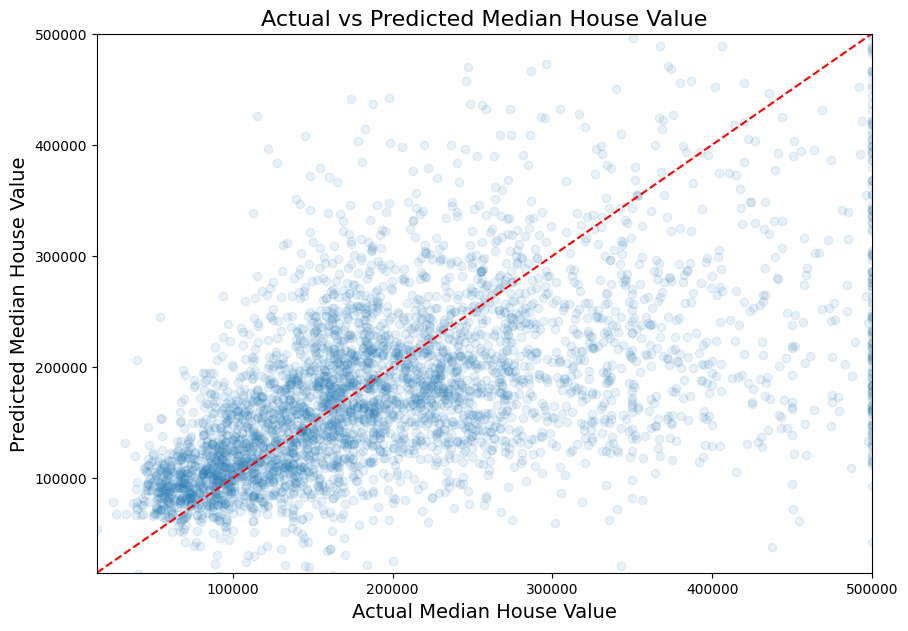

In [18]:
# How is the model performing on the test set?

test_loader = DataLoader(MyDataset(df_test), batch_size=128, shuffle=False)

predictions = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred = predict(X_batch, W, b)
        predictions.append(pred)
        labels.append(y_batch)

predictions = torch.exp(torch.cat(predictions))
labels = torch.exp(torch.cat(labels))

plt.figure(figsize=(10,7))
plt.scatter(labels, predictions, alpha=0.1)
plt.xlabel("Actual Median House Value", fontsize=14)
plt.ylabel("Predicted Median House Value", fontsize=14)
plt.title("Actual vs Predicted Median House Value", fontsize=16)
plt.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--')

plt.xlim(labels.min(), labels.max())
plt.ylim(labels.min(), labels.max())

plt.show()

### R^2 score

To measure how better our model is rather than just predicting the mean value, we can provide the R^2 score

$$R^2 = 1 - \frac{\sum (y - y_{pred})^2}{\sum (y - \hat{y})^2}$$

where $\hat{y}$ is the mean predictor.

In [19]:
# R^2 score for the transformed data (log of the median house value)

log_predictions = torch.log(predictions)
log_labels = torch.log(labels)

ss_total = ((log_labels - log_labels.mean()) ** 2).sum()
ss_residual = ((log_labels - log_predictions) ** 2).sum()

r2_score = 1 - ss_residual / ss_total
print(f"R^2 score: {r2_score.item():.4f}")

R^2 score: 0.1555


In [20]:
# R^2 score for the original data (median house value)

ss_total = ((labels - labels.mean()) ** 2).sum()
ss_residual = ((labels - predictions) ** 2).sum()

r2_score = 1 - ss_residual / ss_total
print(f"R^2 score: {r2_score.item():.4f}")

R^2 score: -60704.8477


> Was this result expected?

## The `nn` module
Instead of directly manipulating tensors and manually updating parameters, the nn module in PyTorch introduces an abstraction layer built around modules, parameters, and composable layers.

### `nn.Module`as a structural abstraction

nn.Module is the base class for all neural network components. It provides:
- Parameter registration
- Hierarchical composition
- Training/evaluation mode switching (`.train()`, `.eval()`)

A model is defined by subclassing nn.Module and implementing forward.

Inside a Module you can choose from a wide list of building blocks, including the matrix multiplication with a weight matrix.

For example, we could completely rewrite the predict function as a forward method in a `LinearRegression` module with a `nn.Linear` layer. 

In [21]:
import torch.nn as nn

class LinearRegression(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.linear(X).squeeze()


Parameters are automatically tracked, gradients are accumulated and handled automatically, we do not own the weights directly.

Optimization is also abstracted with the `optim` module, we only need to define our optimizer and step into it when we want to compute the gradient.


In [27]:
import torch.optim as optim

model = LinearRegression(n_features=12)
optimizer: optim.Optimizer = optim.SGD(model.parameters(), lr=0.001)

The same code then becomes only

In [28]:
train_loader = DataLoader(MyDataset(df_train), batch_size=128, shuffle=True)

n_epochs = 20

losses = []
for epoch in range(n_epochs):

    epoch_loss = 0.0

    for batch, (X_batch, y_batch) in enumerate(train_loader):
        pred = model(X_batch)
        loss = nn.MSELoss()(pred, y_batch)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")

Epoch 1/20, Average Loss: 110.3643
Epoch 2/20, Average Loss: 65.8852
Epoch 3/20, Average Loss: 39.3543
Epoch 4/20, Average Loss: 23.5276
Epoch 5/20, Average Loss: 14.0868
Epoch 6/20, Average Loss: 8.4540
Epoch 7/20, Average Loss: 5.0932
Epoch 8/20, Average Loss: 3.0885
Epoch 9/20, Average Loss: 1.8923
Epoch 10/20, Average Loss: 1.1783
Epoch 11/20, Average Loss: 0.7523
Epoch 12/20, Average Loss: 0.4980
Epoch 13/20, Average Loss: 0.3461
Epoch 14/20, Average Loss: 0.2552
Epoch 15/20, Average Loss: 0.2009
Epoch 16/20, Average Loss: 0.1684
Epoch 17/20, Average Loss: 0.1488
Epoch 18/20, Average Loss: 0.1371
Epoch 19/20, Average Loss: 0.1299
Epoch 20/20, Average Loss: 0.1256


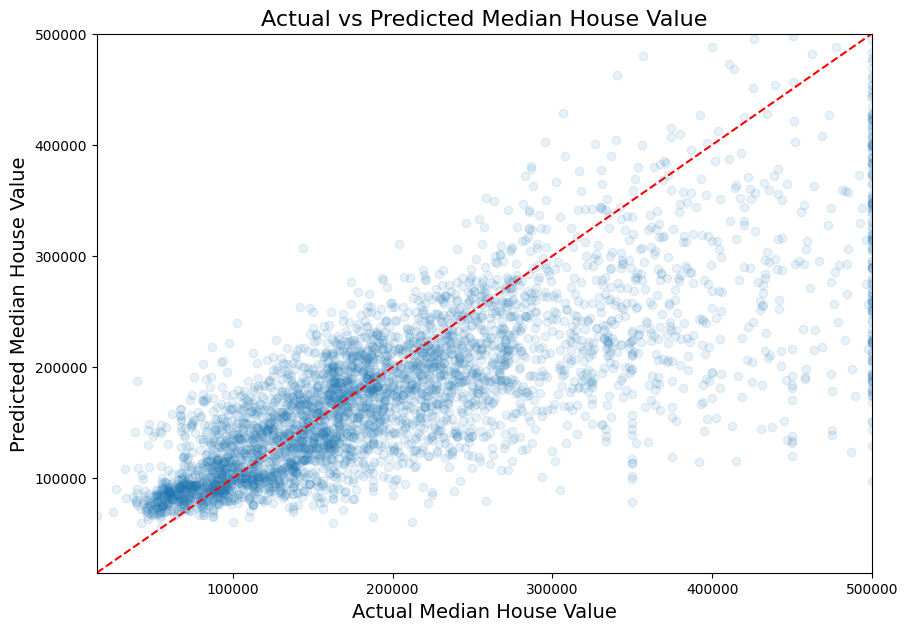

In [29]:
# How is the model performing on the test set?

test_loader = DataLoader(MyDataset(df_test), batch_size=128, shuffle=False)

predictions = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred = model(X_batch)
        predictions.append(pred)
        labels.append(y_batch)

predictions = torch.exp(torch.cat(predictions))
labels = torch.exp(torch.cat(labels))

plt.figure(figsize=(10,7))
plt.scatter(labels, predictions, alpha=0.1)
plt.xlabel("Actual Median House Value", fontsize=14)
plt.ylabel("Predicted Median House Value", fontsize=14)
plt.title("Actual vs Predicted Median House Value", fontsize=16)
plt.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--')

plt.xlim(labels.min(), labels.max())
plt.ylim(labels.min(), labels.max())

plt.show()

With numpy, we would need to implement
- The forward pass
- The gradient computation
- The parameter update

by hand. But PyTorch abstract these away from us
- Forward is implemented in the `nn.Module` class
- Backward is handled by autograd
- Update is delegated to `torch.Optim`